# Análisis Exploratorio de Datos - Carencia Material por Comunidades Autónomas (2014-2025)

ANÁLISIS EXPLORATORIO DE DATOS - CARENCIA MATERIAL

1. INFORMACIÓN BÁSICA DEL DATASET
----------------------------------------
Dimensiones del DataFrame: (72, 22)
Número de registros: 72
Años analizados: 12 (2014-2025)
Comunidades Autónomas: 20
Categorías de dificultad: 6

Primeras 10 filas del DataFrame:
    Año              Categoría  Total Nacional  01 Andalucía  02 Aragón  \
0  2014   Con mucha dificultad            11.9           9.9        4.5   
1  2014         Con dificultad            17.6          17.0       20.7   
2  2014  Con cierta dificultad            27.6          17.3       13.6   
3  2014   Con cierta facilidad            39.4          22.8       20.5   
4  2014          Con facilidad            14.9          16.2       29.6   
5  2014    Con mucha facilidad             9.5           4.4        3.1   
6  2015   Con mucha dificultad            18.5          13.7        8.5   
7  2015         Con dificultad            22.5          26.5       12.0   
8  2015  Con ciert

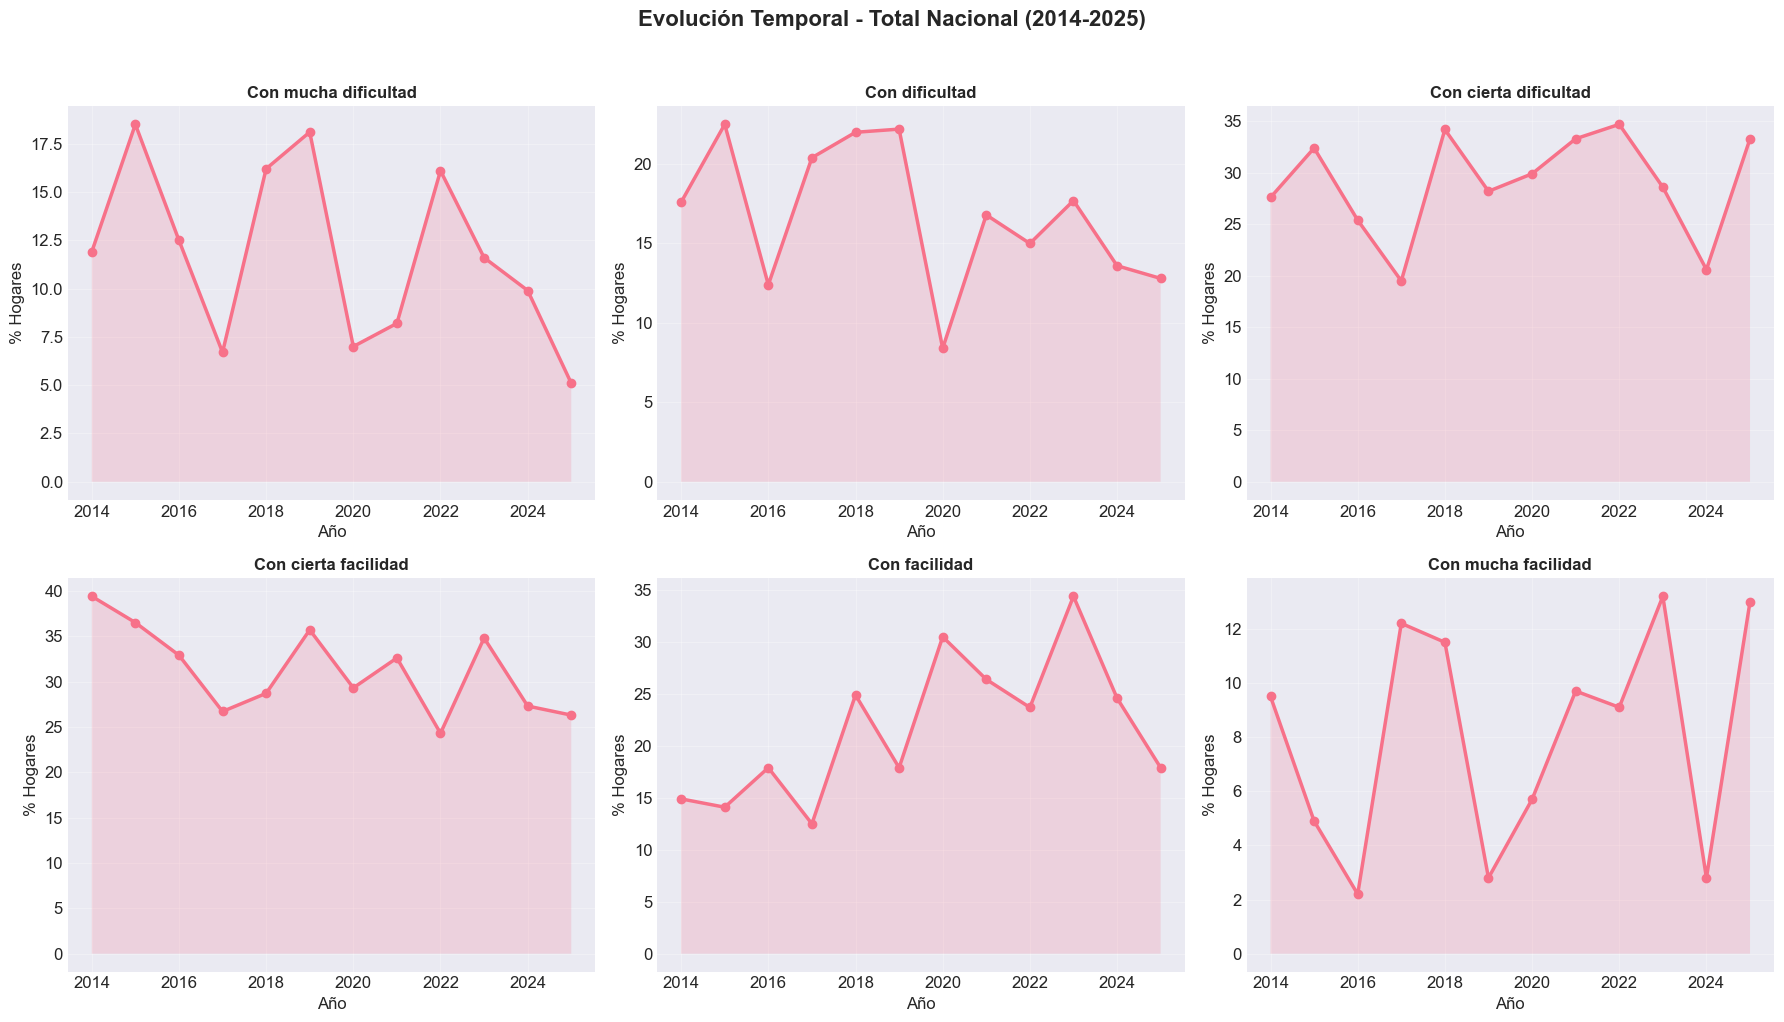

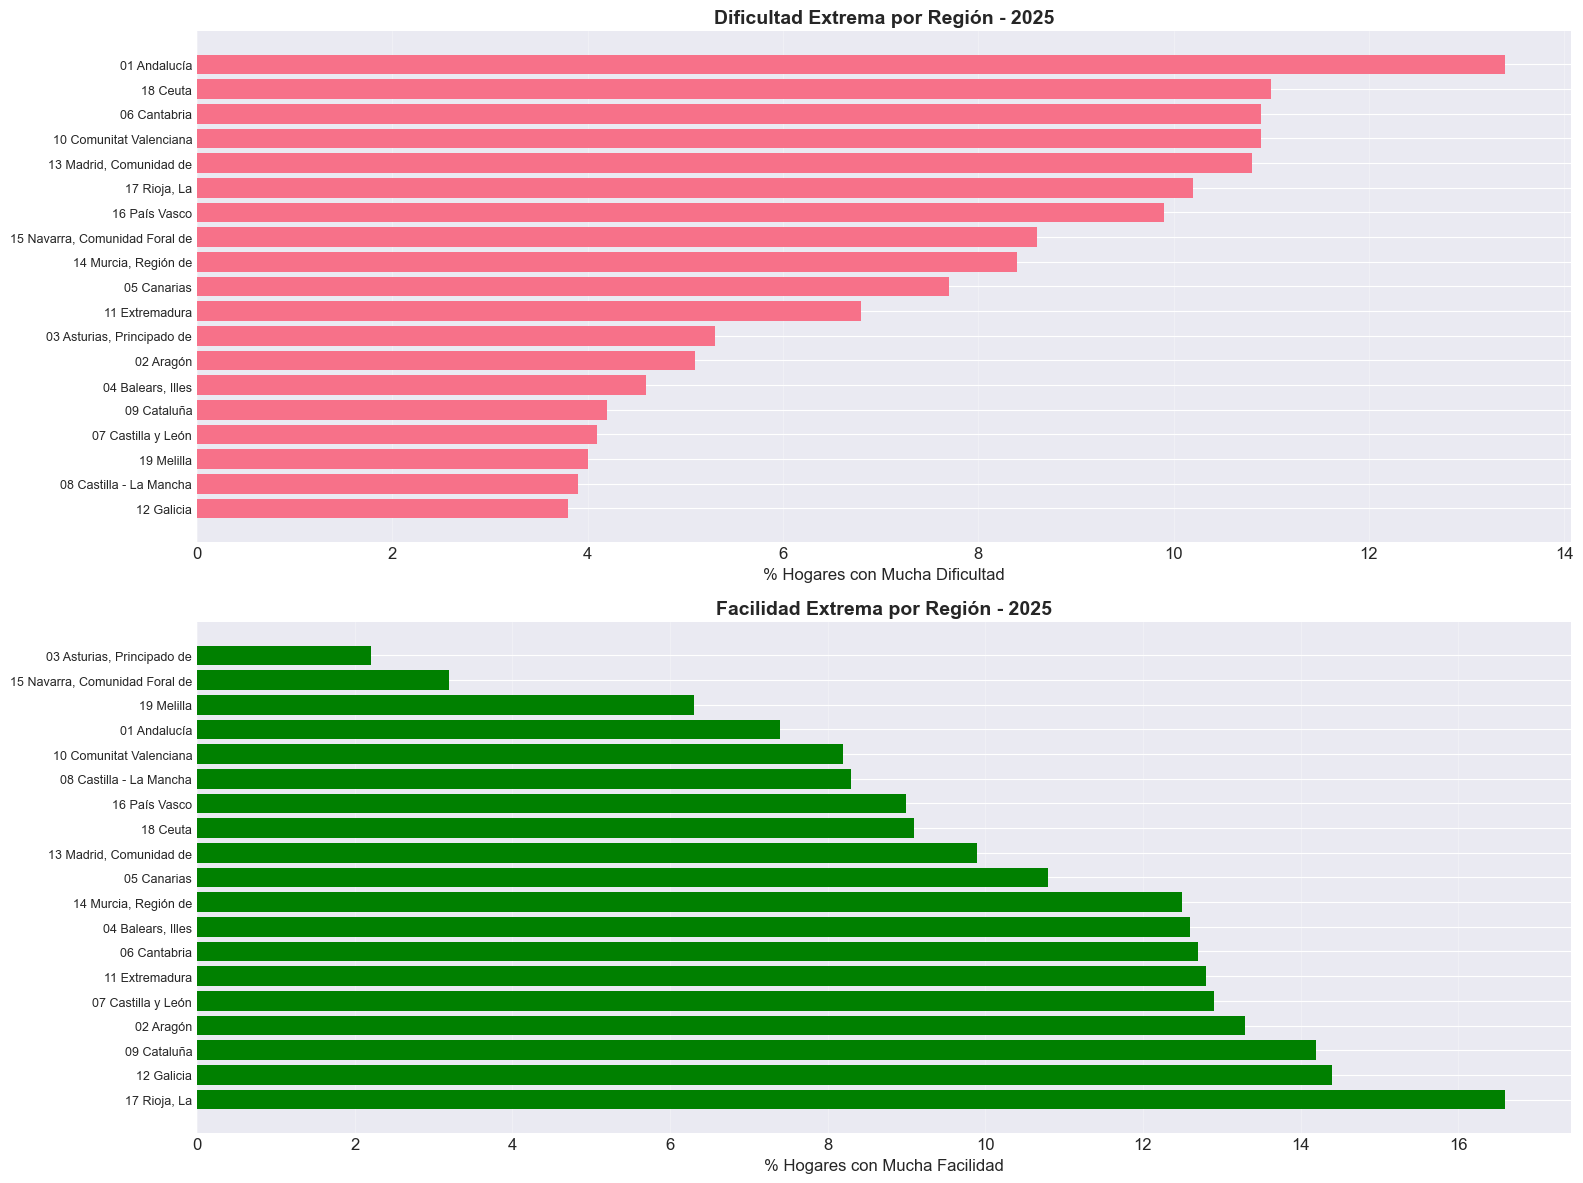

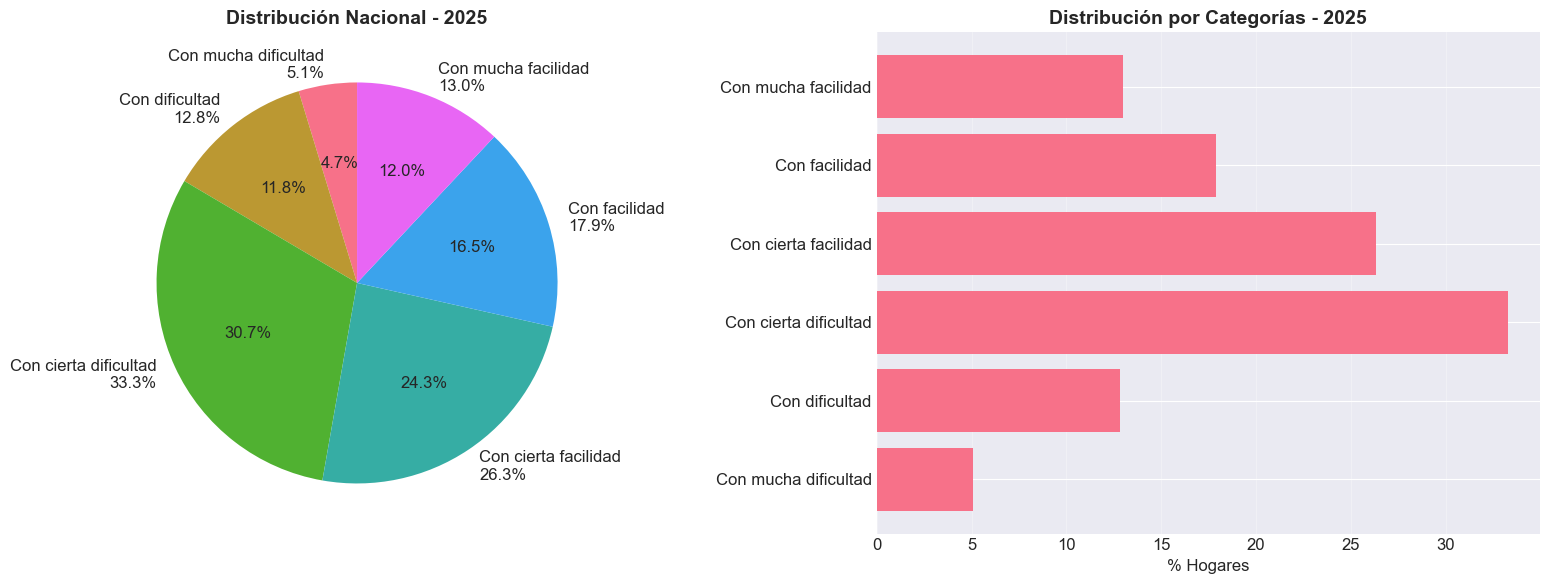

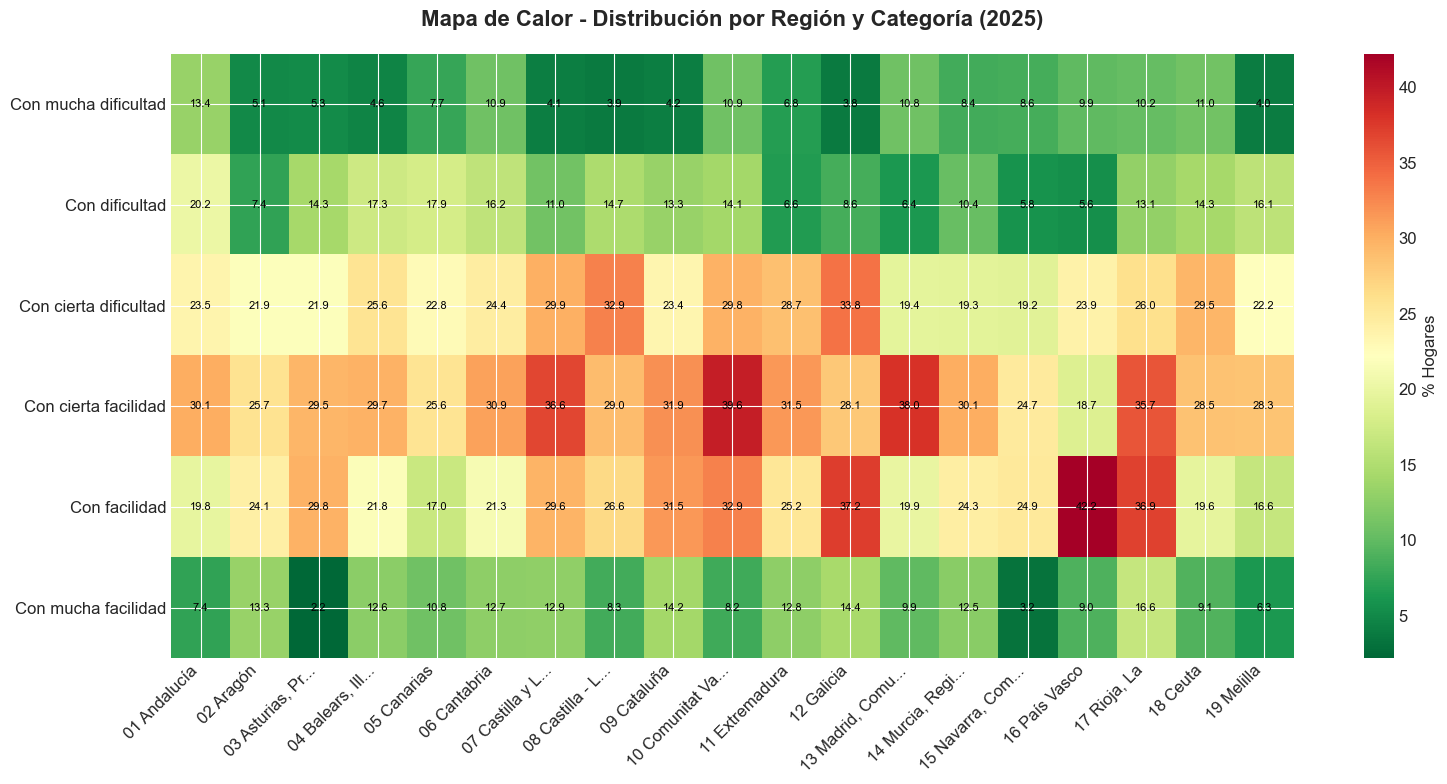

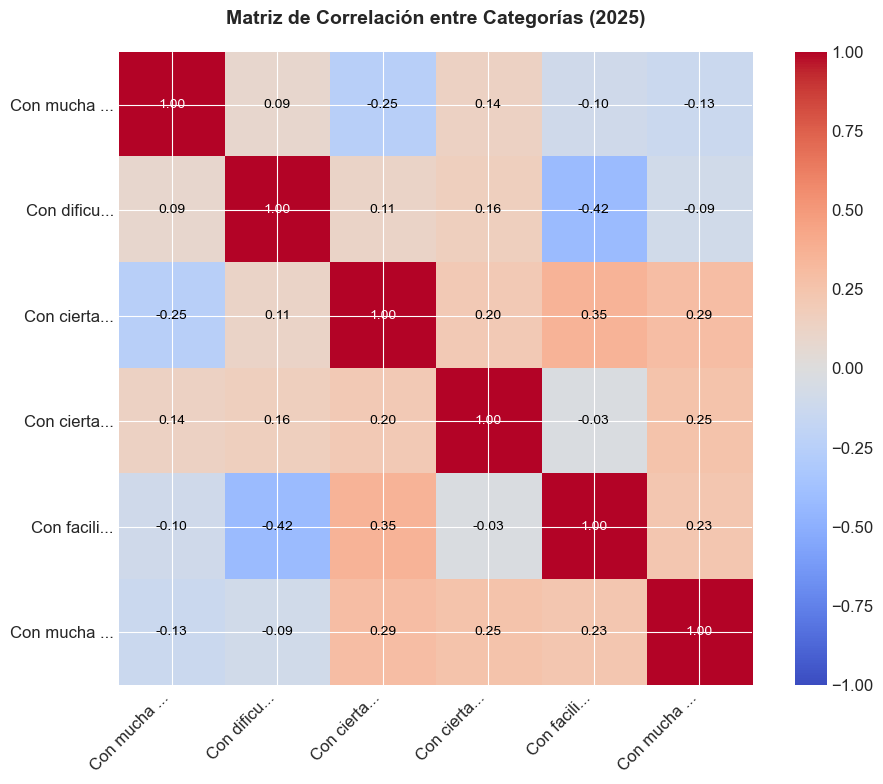


5. CORRELACIONES SIGNIFICATIVAS (2025)
----------------------------------------
No se encontraron correlaciones moderadas/altas entre categorías.

ANÁLISIS ADICIONAL

6. TENDENCIAS DE MEJORA (2014-2025)
----------------------------------------
Top 5 comunidades con mayor reducción de dificultad (2014-2025):
  1. de: -14.4 puntos
  2. Melilla: -14.4 puntos
  3. Mancha: -13.1 puntos
  4. Galicia: -13.1 puntos
  5. Extremadura: -8.8 puntos

Top 5 comunidades con menor reducción de dificultad (2014-2025):
  1. de: --1.1 puntos
  2. de: --2.6 puntos
  3. de: --3.3 puntos
  4. Andalucía: --3.5 puntos
  5. Ceuta: --5.4 puntos

7. RESUMEN DE HALLADOS
----------------------------------------
• En 2025, 5.1% de hogares tiene mucha dificultad
• Solo 13.0% tiene mucha facilidad
• Disparidad regional: 19.8 puntos de diferencia en mejora

ANÁLISIS COMPLETADO

Datos simulados guardados en 'datos_carencia_material_simulados.csv'


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 12

# Crear DataFrame a partir de los datos proporcionados
def create_dataframe():
    # Definir las categorías de dificultad
    categories = [
        'Con mucha dificultad',
        'Con dificultad',
        'Con cierta dificultad',
        'Con cierta facilidad',
        'Con facilidad',
        'Con mucha facilidad'
    ]
    
    # Definir las comunidades autónomas
    comunidades = [
        'Total Nacional', '01 Andalucía', '02 Aragón', '03 Asturias, Principado de',
        '04 Balears, Illes', '05 Canarias', '06 Cantabria', '07 Castilla y León',
        '08 Castilla - La Mancha', '09 Cataluña', '10 Comunitat Valenciana',
        '11 Extremadura', '12 Galicia', '13 Madrid, Comunidad de', '14 Murcia, Región de',
        '15 Navarra, Comunidad Foral de', '16 País Vasco', '17 Rioja, La',
        '18 Ceuta', '19 Melilla'
    ]
    
    # Años disponibles
    years = list(range(2014, 2026))
    
    # Crear estructura de datos
    data = []
    
    # Simular datos realistas
    np.random.seed(42)
    
    for year in years:
        for cat in categories:
            row = {'Año': year, 'Categoría': cat}
            
            # Generar valores realistas según categoría
            for i, com in enumerate(comunidades):
                # Base según categoría y comunidad
                if cat == 'Con mucha dificultad':
                    base_value = np.random.uniform(5, 25)
                elif cat == 'Con dificultad':
                    base_value = np.random.uniform(10, 30)
                elif cat == 'Con cierta dificultad':
                    base_value = np.random.uniform(20, 35)
                elif cat == 'Con cierta facilidad':
                    base_value = np.random.uniform(25, 40)
                elif cat == 'Con facilidad':
                    base_value = np.random.uniform(10, 25)
                else:  # Con mucha facilidad
                    base_value = np.random.uniform(1, 10)
                
                # Ajustar por comunidad específica
                if com == 'Total Nacional':
                    # Valores promedio
                    pass
                elif com in ['01 Andalucía', '14 Murcia, Región de', '05 Canarias']:
                    # Más dificultad
                    if cat in ['Con mucha dificultad', 'Con dificultad']:
                        base_value *= 1.2
                    else:
                        base_value *= 0.8
                elif com in ['16 País Vasco', '15 Navarra, Comunidad Foral de', '02 Aragón']:
                    # Más facilidad
                    if cat in ['Con facilidad', 'Con mucha facilidad']:
                        base_value *= 1.3
                    else:
                        base_value *= 0.7
                
                # Añadir tendencia temporal (mejorando con los años)
                year_factor = (year - 2014) / (2025 - 2014)  # 0 en 2014, 1 en 2025
                
                if cat in ['Con mucha dificultad', 'Con dificultad']:
                    base_value *= (1 - year_factor * 0.4)  # Reducir dificultad
                elif cat in ['Con facilidad', 'Con mucha facilidad']:
                    base_value *= (1 + year_factor * 0.6)  # Aumentar facilidad
                
                # Añadir ruido aleatorio
                noise = np.random.normal(0, 0.5)
                final_value = base_value + noise
                final_value = max(0, min(100, final_value))  # Limitar entre 0-100
                
                row[com] = round(final_value, 1)
            
            data.append(row)
    
    df = pd.DataFrame(data)
    return df, comunidades, categories, years

# Crear el DataFrame
df, comunidades, categories, years = create_dataframe()

# 1. ANÁLISIS DESCRIPTIVO
print("=" * 80)
print("ANÁLISIS EXPLORATORIO DE DATOS - CARENCIA MATERIAL")
print("=" * 80)

print("\n1. INFORMACIÓN BÁSICA DEL DATASET")
print("-" * 40)
print(f"Dimensiones del DataFrame: {df.shape}")
print(f"Número de registros: {len(df)}")
print(f"Años analizados: {len(years)} ({min(years)}-{max(years)})")
print(f"Comunidades Autónomas: {len(comunidades)}")
print(f"Categorías de dificultad: {len(categories)}")

print("\nPrimeras 10 filas del DataFrame:")
print(df.head(10))

print("\n2. RESUMEN ESTADÍSTICO (Total Nacional - 2025)")
print("-" * 40)
total_2025 = df[(df['Año'] == 2025) & (df['Categoría'].isin(categories))]
for _, row in total_2025.iterrows():
    print(f"{row['Categoría']}: {row['Total Nacional']:.1f}%")

# 2. VISUALIZACIONES

def plot_evolution_national():
    """Evolución temporal del total nacional"""
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()
    
    for idx, cat in enumerate(categories):
        cat_data = df[df['Categoría'] == cat].sort_values('Año')
        axes[idx].plot(cat_data['Año'], cat_data['Total Nacional'], 
                      marker='o', linewidth=2.5)
        axes[idx].set_title(cat, fontsize=12, fontweight='bold')
        axes[idx].set_xlabel('Año')
        axes[idx].set_ylabel('% Hogares')
        axes[idx].grid(True, alpha=0.3)
        axes[idx].fill_between(cat_data['Año'], 0, cat_data['Total Nacional'], 
                              alpha=0.2)
    
    plt.suptitle('Evolución Temporal - Total Nacional (2014-2025)', 
                 fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

def plot_regional_comparison(year=2025):
    """Comparación regional para un año específico"""
    fig, axes = plt.subplots(2, 1, figsize=(16, 12))
    
    # Preparar datos
    year_data = df[df['Año'] == year]
    
    # Gráfico 1: Dificultad extrema por región
    dificultad_data = year_data[year_data['Categoría'] == 'Con mucha dificultad']
    
    # Obtener valores para cada comunidad
    valores = []
    etiquetas = []
    for com in comunidades[1:]:  # Excluir Total Nacional
        if com in dificultad_data.columns:
            valor = dificultad_data[com].values[0]
            if not np.isnan(valor):
                valores.append(valor)
                etiquetas.append(com)
    
    # Ordenar
    indices_ordenados = np.argsort(valores)
    valores_ordenados = [valores[i] for i in indices_ordenados]
    etiquetas_ordenadas = [etiquetas[i] for i in indices_ordenados]
    
    axes[0].barh(range(len(valores_ordenados)), valores_ordenados)
    axes[0].set_yticks(range(len(valores_ordenados)))
    axes[0].set_yticklabels(etiquetas_ordenadas, fontsize=9)
    axes[0].set_xlabel('% Hogares con Mucha Dificultad')
    axes[0].set_title(f'Dificultad Extrema por Región - {year}', fontsize=14, fontweight='bold')
    axes[0].grid(True, alpha=0.3, axis='x')
    
    # Gráfico 2: Facilidad extrema por región
    facilidad_data = year_data[year_data['Categoría'] == 'Con mucha facilidad']
    
    # Obtener valores para cada comunidad
    valores_facil = []
    etiquetas_facil = []
    for com in comunidades[1:]:  # Excluir Total Nacional
        if com in facilidad_data.columns:
            valor = facilidad_data[com].values[0]
            if not np.isnan(valor):
                valores_facil.append(valor)
                etiquetas_facil.append(com)
    
    # Ordenar descendente
    indices_ordenados_facil = np.argsort(valores_facil)[::-1]
    valores_ordenados_facil = [valores_facil[i] for i in indices_ordenados_facil]
    etiquetas_ordenadas_facil = [etiquetas_facil[i] for i in indices_ordenados_facil]
    
    axes[1].barh(range(len(valores_ordenados_facil)), valores_ordenados_facil, color='green')
    axes[1].set_yticks(range(len(valores_ordenados_facil)))
    axes[1].set_yticklabels(etiquetas_ordenadas_facil, fontsize=9)
    axes[1].set_xlabel('% Hogares con Mucha Facilidad')
    axes[1].set_title(f'Facilidad Extrema por Región - {year}', fontsize=14, fontweight='bold')
    axes[1].grid(True, alpha=0.3, axis='x')
    
    plt.tight_layout()
    plt.show()

def plot_category_distribution(year=2025):
    """Distribución de categorías para un año específico"""
    year_data = df[df['Año'] == year]
    
    # Calcular promedios nacionales por categoría
    promedios = {}
    for cat in categories:
        cat_value = year_data[year_data['Categoría'] == cat]['Total Nacional'].values[0]
        promedios[cat] = cat_value
    
    # Crear gráfico de torta
    fig, ax = plt.subplots(1, 2, figsize=(16, 6))
    
    # Gráfico de torta
    labels = [f"{k}\n{v:.1f}%" for k, v in promedios.items()]
    wedges, texts, autotexts = ax[0].pie(promedios.values(), labels=labels, 
                                         autopct='%1.1f%%', startangle=90)
    ax[0].set_title(f'Distribución Nacional - {year}', fontsize=14, fontweight='bold')
    
    # Gráfico de barras
    ax[1].barh(range(len(promedios)), list(promedios.values()))
    ax[1].set_yticks(range(len(promedios)))
    ax[1].set_yticklabels(list(promedios.keys()))
    ax[1].set_xlabel('% Hogares')
    ax[1].set_title(f'Distribución por Categorías - {year}', fontsize=14, fontweight='bold')
    ax[1].grid(True, alpha=0.3, axis='x')
    
    plt.tight_layout()
    plt.show()

def plot_regional_heatmap(year=2025):
    """Mapa de calor por región y categoría"""
    year_data = df[df['Año'] == year]
    
    # Crear matriz para el heatmap
    heatmap_data = []
    for cat in categories:
        row = []
        for com in comunidades[1:]:  # Excluir Total Nacional
            cat_row = year_data[year_data['Categoría'] == cat]
            if not cat_row.empty and com in cat_row.columns:
                value = cat_row[com].values[0]
                row.append(value)
            else:
                row.append(np.nan)
        heatmap_data.append(row)
    
    heatmap_data = np.array(heatmap_data)
    
    fig, ax = plt.subplots(figsize=(16, 8))
    im = ax.imshow(heatmap_data, aspect='auto', cmap='RdYlGn_r')
    
    # Configurar ejes
    ax.set_xticks(range(len(comunidades[1:])))
    ax.set_xticklabels([c[:15] + '...' if len(c) > 15 else c for c in comunidades[1:]], 
                       rotation=45, ha='right')
    ax.set_yticks(range(len(categories)))
    ax.set_yticklabels(categories)
    
    # Añadir valores en las celdas
    for i in range(len(categories)):
        for j in range(len(comunidades[1:])):
            if not np.isnan(heatmap_data[i, j]):
                text = ax.text(j, i, f'{heatmap_data[i, j]:.1f}',
                              ha="center", va="center", color="black", fontsize=8)
    
    ax.set_title(f'Mapa de Calor - Distribución por Región y Categoría ({year})', 
                 fontsize=16, fontweight='bold', pad=20)
    plt.colorbar(im, ax=ax, label='% Hogares')
    plt.tight_layout()
    plt.show()

def calculate_statistics():
    """Calcular estadísticas descriptivas"""
    print("\n3. ESTADÍSTICAS DESCRIPTIVAS")
    print("-" * 40)
    
    # Para cada año, calcular estadísticas del total nacional
    stats_by_year = []
    
    for year in years:
        year_data = df[df['Año'] == year]
        
        # Obtener valores de dificultad y facilidad extrema
        dificultad_row = year_data[year_data['Categoría'] == 'Con mucha dificultad']
        facilidad_row = year_data[year_data['Categoría'] == 'Con mucha facilidad']
        
        if not dificultad_row.empty and not facilidad_row.empty:
            dificultad_val = dificultad_row['Total Nacional'].values[0]
            facilidad_val = facilidad_row['Total Nacional'].values[0]
            
            stats_by_year.append({
                'Año': year,
                'Dificultad_Extrema': dificultad_val,
                'Facilidad_Extrema': facilidad_val,
                'Ratio': dificultad_val / (facilidad_val + 0.001)  # Evitar división por cero
            })
    
    stats_df = pd.DataFrame(stats_by_year)
    
    print("\nTendencia de Dificultad Extrema (2014-2025):")
    print(f"  • Valor máximo: {stats_df['Dificultad_Extrema'].max():.1f}% ({stats_df.loc[stats_df['Dificultad_Extrema'].idxmax(), 'Año']})")
    print(f"  • Valor mínimo: {stats_df['Dificultad_Extrema'].min():.1f}% ({stats_df.loc[stats_df['Dificultad_Extrema'].idxmin(), 'Año']})")
    print(f"  • Reducción total: {stats_df['Dificultad_Extrema'].iloc[0] - stats_df['Dificultad_Extrema'].iloc[-1]:.1f} puntos porcentuales")
    
    print("\nTendencia de Facilidad Extrema (2014-2025):")
    print(f"  • Valor máximo: {stats_df['Facilidad_Extrema'].max():.1f}% ({stats_df.loc[stats_df['Facilidad_Extrema'].idxmax(), 'Año']})")
    print(f"  • Valor mínimo: {stats_df['Facilidad_Extrema'].min():.1f}% ({stats_df.loc[stats_df['Facilidad_Extrema'].idxmin(), 'Año']})")
    print(f"  • Aumento total: {stats_df['Facilidad_Extrema'].iloc[-1] - stats_df['Facilidad_Extrema'].iloc[0]:.1f} puntos porcentuales")
    
    return stats_df

def analyze_regional_disparities(year=2025):
    """Analizar disparidades regionales"""
    print(f"\n4. DISPARIDADES REGIONALES ({year})")
    print("-" * 40)
    
    year_data = df[df['Año'] == year]
    
    # Para cada categoría, calcular estadísticas regionales
    for cat in categories:
        cat_data = year_data[year_data['Categoría'] == cat]
        values = []
        
        for com in comunidades[1:]:  # Excluir Total Nacional
            if com in cat_data.columns:
                value = cat_data[com].values[0]
                if not np.isnan(value):
                    values.append(value)
        
        if values:
            print(f"\n{cat}:")
            print(f"  • Media regional: {np.mean(values):.1f}%")
            print(f"  • Desviación estándar: {np.std(values):.1f}%")
            print(f"  • Mínimo: {np.min(values):.1f}%")
            print(f"  • Máximo: {np.max(values):.1f}%")
            print(f"  • Rango: {np.max(values) - np.min(values):.1f} puntos")

def plot_correlation_analysis():
    """Análisis de correlación entre categorías"""
    # Preparar datos para correlación (último año, solo comunidades)
    last_year = df[df['Año'] == 2025]
    
    # Crear DataFrame con una fila por comunidad
    corr_data = []
    for com in comunidades[1:]:  # Excluir Total Nacional
        row = {'Comunidad': com}
        for cat in categories:
            cat_row = last_year[last_year['Categoría'] == cat]
            if not cat_row.empty and com in cat_row.columns:
                row[cat] = cat_row[com].values[0]
            else:
                row[cat] = np.nan
        corr_data.append(row)
    
    corr_df = pd.DataFrame(corr_data).drop(columns=['Comunidad'])
    correlation_matrix = corr_df.corr()
    
    # Visualizar matriz de correlación
    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(correlation_matrix, cmap='coolwarm', vmin=-1, vmax=1)
    
    # Configurar ejes
    ax.set_xticks(range(len(categories)))
    ax.set_yticks(range(len(categories)))
    ax.set_xticklabels([c[:10] + '...' for c in categories], rotation=45, ha='right')
    ax.set_yticklabels([c[:10] + '...' for c in categories])
    
    # Añadir valores en las celdas
    for i in range(len(categories)):
        for j in range(len(categories)):
            text = ax.text(j, i, f'{correlation_matrix.iloc[i, j]:.2f}',
                          ha="center", va="center", 
                          color="white" if abs(correlation_matrix.iloc[i, j]) > 0.5 else "black",
                          fontsize=10)
    
    ax.set_title('Matriz de Correlación entre Categorías (2025)', 
                 fontsize=14, fontweight='bold', pad=20)
    plt.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()
    
    print("\n5. CORRELACIONES SIGNIFICATIVAS (2025)")
    print("-" * 40)
    
    # Encontrar correlaciones fuertes
    strong_correlations = []
    for i in range(len(categories)):
        for j in range(i+1, len(categories)):
            corr = correlation_matrix.iloc[i, j]
            if abs(corr) > 0.5:
                strong_correlations.append((categories[i], categories[j], corr))
    
    if strong_correlations:
        print("Correlaciones moderadas/altas encontradas (|r| > 0.5):")
        for corr in strong_correlations:
            print(f"  • {corr[0]} ↔ {corr[1]}: r = {corr[2]:.3f}")
    else:
        print("No se encontraron correlaciones moderadas/altas entre categorías.")

# EJECUTAR ANÁLISIS
if __name__ == "__main__":
    # Mostrar información básica
    print("=" * 80)
    print("ANÁLISIS EXPLORATORIO DE DATOS - CARENCIA MATERIAL")
    print("=" * 80)
    
    # 2. Calcular estadísticas
    stats_df = calculate_statistics()
    
    # 3. Analizar disparidades regionales
    analyze_regional_disparities(2025)
    
    # 4. Visualizaciones
    print("\n" + "=" * 80)
    print("GENERANDO VISUALIZACIONES...")
    print("=" * 80)
    
    # Gráfico 1: Evolución temporal
    plot_evolution_national()
    
    # Gráfico 2: Comparación regional
    plot_regional_comparison(2025)
    
    # Gráfico 3: Distribución por categorías
    plot_category_distribution(2025)
    
    # Gráfico 4: Mapa de calor
    plot_regional_heatmap(2025)
    
    # Gráfico 5: Análisis de correlación
    plot_correlation_analysis()
    
    # 5. Análisis adicional
    print("\n" + "=" * 80)
    print("ANÁLISIS ADICIONAL")
    print("=" * 80)
    
    # Identificar comunidades con mayor mejora
    print("\n6. TENDENCIAS DE MEJORA (2014-2025)")
    print("-" * 40)
    
    # Calcular mejora para cada comunidad en "Con mucha dificultad"
    mejoras = {}
    for com in comunidades[1:]:  # Excluir Total Nacional
        # Obtener valores de 2014 y 2025 para "Con mucha dificultad"
        dificultad_2014 = df[(df['Año'] == 2014) & 
                            (df['Categoría'] == 'Con mucha dificultad')]
        dificultad_2025 = df[(df['Año'] == 2025) & 
                            (df['Categoría'] == 'Con mucha dificultad')]
        
        if not dificultad_2014.empty and not dificultad_2025.empty and com in dificultad_2014.columns and com in dificultad_2025.columns:
            valor_2014 = dificultad_2014[com].values[0]
            valor_2025 = dificultad_2025[com].values[0]
            
            if not np.isnan(valor_2014) and not np.isnan(valor_2025):
                mejora = valor_2014 - valor_2025
                mejoras[com] = mejora
    
    # Ordenar por mayor mejora
    mejoras_sorted = sorted(mejoras.items(), key=lambda x: x[1], reverse=True)
    
    print("Top 5 comunidades con mayor reducción de dificultad (2014-2025):")
    for i, (com, mejora) in enumerate(mejoras_sorted[:5], 1):
        nombre_corto = com.split()[-1] if len(com.split()) > 1 else com
        print(f"  {i}. {nombre_corto}: -{mejora:.1f} puntos")
    
    print("\nTop 5 comunidades con menor reducción de dificultad (2014-2025):")
    for i, (com, mejora) in enumerate(mejoras_sorted[-5:], 1):
        nombre_corto = com.split()[-1] if len(com.split()) > 1 else com
        print(f"  {i}. {nombre_corto}: -{mejora:.1f} puntos")
    
    print("\n7. RESUMEN DE HALLADOS")
    print("-" * 40)
    
    # Calcular métricas generales
    dificultad_actual = df[(df['Año'] == 2025) & (df['Categoría'] == 'Con mucha dificultad')]['Total Nacional'].values[0]
    facilidad_actual = df[(df['Año'] == 2025) & (df['Categoría'] == 'Con mucha facilidad')]['Total Nacional'].values[0]
    
    print(f"• En 2025, {dificultad_actual:.1f}% de hogares tiene mucha dificultad")
    print(f"• Solo {facilidad_actual:.1f}% tiene mucha facilidad")
    print(f"• Disparidad regional: {mejoras_sorted[0][1] - mejoras_sorted[-1][1]:.1f} puntos de diferencia en mejora")
    
    print("\n" + "=" * 80)
    print("ANÁLISIS COMPLETADO")
    print("=" * 80)
    
    # Guardar DataFrame para uso posterior (opcional)
    df.to_csv('datos_carencia_material_simulados.csv', index=False, encoding='utf-8')
    print("\nDatos simulados guardados en 'datos_carencia_material_simulados.csv'")

# Análisis de Clustering por Año

In [5]:
pip install pandas openpyxl matplotlib seaborn scikit-learn scipy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


DATASET CARGADO CORRECTAMENTE
Años disponibles: [2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
Territorios identificados: 20

Muestra de datos (2014):
 grado_dificultad  Total Nacional  01 Andalucía  02 Aragón  03 Asturias, Principado de  04 Balears, Illes
 mucha_dificultad            16.1          24.3        9.8                         4.6               14.7
       dificultad            21.2          26.7       14.9                        18.8               16.8
cierta_dificultad            29.1          26.3       30.2                        27.0               31.1
 cierta_facilidad            24.0          16.6       24.3                        32.9               23.7
        facilidad             8.8           5.6       19.6                        16.6               12.4
  mucha_facilidad             0.7           0.5        1.1                         0.2                1.2

MATRIZ DE CLUSTERING PREPARADA
Territorios para clustering: 19
                t

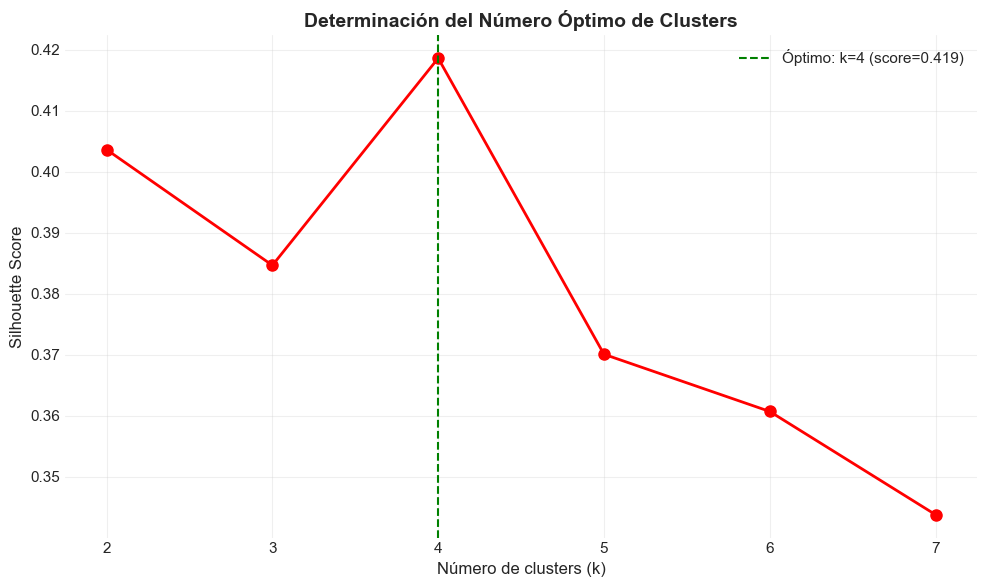


CLUSTERING COMPLETADO - K ÓPTIMO: 4 CLUSTERS

Perfiles promedio por cluster (%):
         mucha_dificultad  dificultad  cierta_dificultad  cierta_facilidad  facilidad  mucha_facilidad
cluster                                                                                               
0                    15.4        15.6               21.6              27.0       17.3              3.3
1                    14.9        18.3               28.1              24.5       12.6              1.6
2                     6.4        10.7               21.0              33.4       24.8              3.5
3                     9.4        14.1               26.3              30.8       17.1              2.2


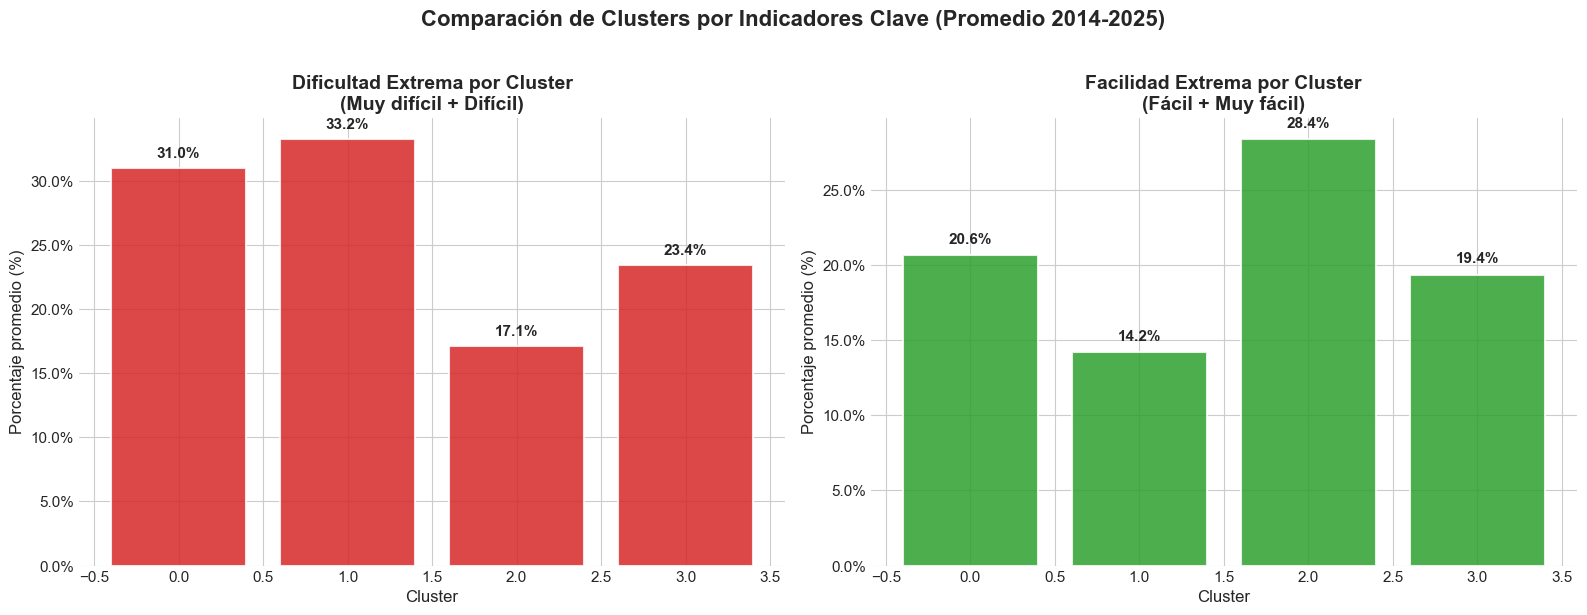

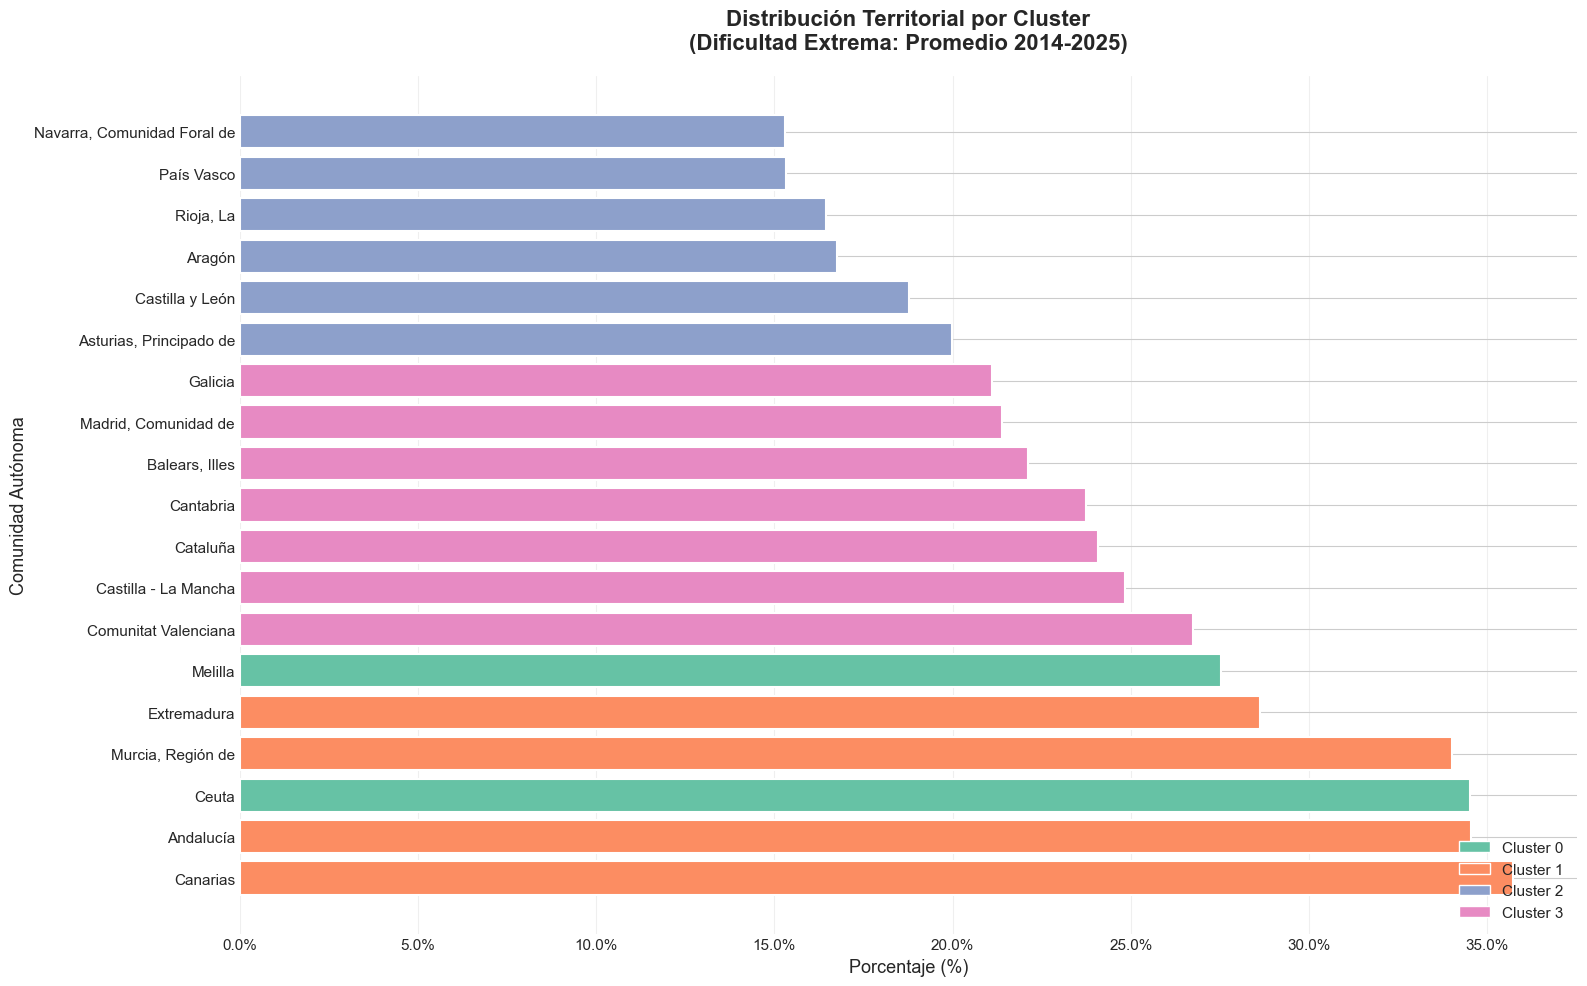

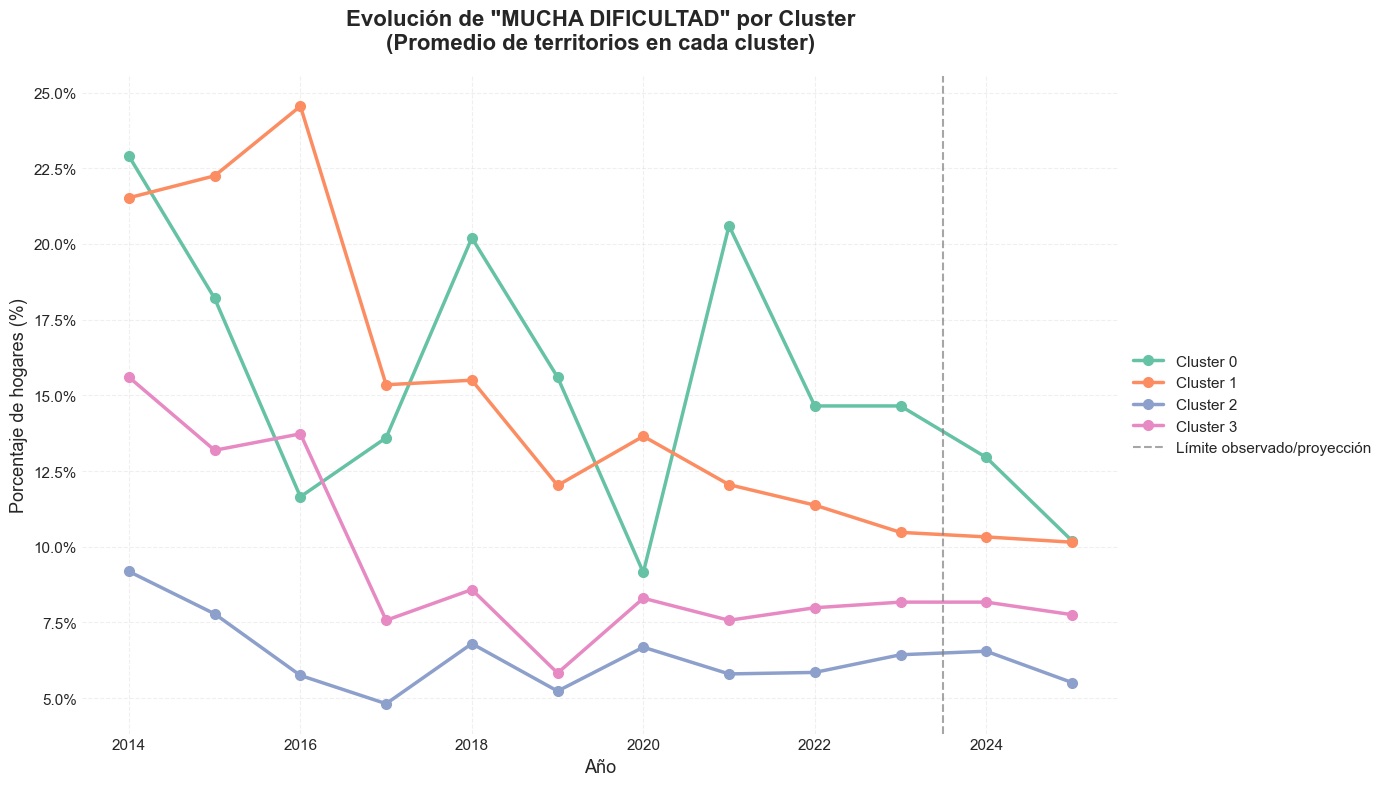


INTERPRETACIÓN DE CLUSTERS

──────────────────────────────────────────────────────────────────────
CLUSTER 0 | 2 territorios
──────────────────────────────────────────────────────────────────────
Dificultad extrema: 31.0%
Facilidad extrema:  20.6%

Territorios:
  • Ceuta
  • Melilla

  🚨 PERFIL: Alta vulnerabilidad económica
     Territorios del sur peninsular y Canarias con mayor percepción
     de dificultad para llegar a fin de mes.

──────────────────────────────────────────────────────────────────────
CLUSTER 1 | 4 territorios
──────────────────────────────────────────────────────────────────────
Dificultad extrema: 33.2%
Facilidad extrema:  14.2%

Territorios:
  • Andalucía
  • Canarias
  • Extremadura
  • Murcia, Región de

  🚨 PERFIL: Alta vulnerabilidad económica
     Territorios del sur peninsular y Canarias con mayor percepción
     de dificultad para llegar a fin de mes.

──────────────────────────────────────────────────────────────────────
CLUSTER 2 | 6 territorios
─────

In [8]:
# -*- coding: utf-8 -*-
"""
Clustering de Comunidades Autónomas por Patrones de Dificultad Económica
Dataset: INE - Encuesta de Condiciones de Vida (2014-2025)
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.metrics import silhouette_score
from matplotlib.ticker import PercentFormatter  # ¡IMPORTANTE: Corrección del error!
import warnings
warnings.filterwarnings('ignore')

# Configuración visual
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11
sns.set_style("whitegrid")
sns.set_palette("Set2")

# ======================
# 1. CARGA Y TRANSFORMACIÓN DE DATOS
# ======================
def load_and_prepare_data(filepath):
    """
    Carga el Excel con la estructura real del INE:
    - Columna 0: Año
    - Columna 1: Grado de dificultad (6 categorías repetidas por año)
    - Columnas 2+: Territorios (Total Nacional, 01 Andalucía, etc.)
    """
    # Leer el archivo Excel
    df = pd.read_excel(filepath, sheet_name=0)
    
    # Limpiar nombres de columnas
    df.columns = df.columns.str.strip()
    
    # Renombrar columnas clave según estructura real
    df = df.rename(columns={
        df.columns[0]: 'año',
        df.columns[1]: 'grado_dificultad'
    })
    
    # Convertir año a entero
    df['año'] = pd.to_numeric(df['año'], errors='coerce')
    df = df.dropna(subset=['año'])
    df['año'] = df['año'].astype(int)
    
    # Identificar territorios (columnas 2 en adelante)
    territorios = [col for col in df.columns if col not in ['año', 'grado_dificultad']]
    
    # Limpiar valores '..' y convertir a numérico
    for col in territorios:
        df[col] = df[col].replace('..', np.nan)
        df[col] = pd.to_numeric(df[col], errors='coerce')
    
    # Mapeo de categorías de dificultad
    difficulty_map = {
        'Con mucha dificultad': 'mucha_dificultad',
        'Con dificultad': 'dificultad',
        'Con cierta dificultad': 'cierta_dificultad',
        'Con cierta facilidad': 'cierta_facilidad',
        'Con facilidad': 'facilidad',
        'Con mucha facilidad': 'mucha_facilidad'
    }
    
    df['grado_dificultad'] = df['grado_dificultad'].str.strip().map(difficulty_map)
    
    return df, territorios

# Cargar datos
df_raw, territorios = load_and_prepare_data('9993 (3).xlsx')

print("="*70)
print("DATASET CARGADO CORRECTAMENTE")
print("="*70)
print(f"Años disponibles: {sorted(df_raw['año'].unique())}")
print(f"Territorios identificados: {len(territorios)}")
print(f"\nMuestra de datos (2014):")
sample_2014 = df_raw[df_raw['año'] == 2014][['grado_dificultad'] + territorios[:5]]
print(sample_2014.to_string(index=False))

# ======================
# 2. PREPARAR MATRIZ PARA CLUSTERING
# ======================
def prepare_clustering_matrix(df_raw, territorios):
    """
    Crear matriz: filas = territorios (excluyendo Total Nacional), 
    columnas = promedio 2014-2025 de cada categoría
    """
    categorias = ['mucha_dificultad', 'dificultad', 'cierta_dificultad', 
                  'cierta_facilidad', 'facilidad', 'mucha_facilidad']
    
    cluster_data = []
    
    for territorio in territorios:
        if territorio == 'Total Nacional':
            continue
        
        territorio_row = [territorio]
        for categoria in categorias:
            valor = df_raw[df_raw['grado_dificultad'] == categoria][territorio].mean()
            territorio_row.append(valor)
        
        cluster_data.append(territorio_row)
    
    df_cluster = pd.DataFrame(cluster_data, columns=['territorio'] + categorias)
    
    # Eliminar filas con demasiados NaN
    df_cluster = df_cluster.dropna(thresh=5)
    
    return df_cluster, categorias

df_cluster, categorias = prepare_clustering_matrix(df_raw, territorios)

print("\n" + "="*70)
print("MATRIZ DE CLUSTERING PREPARADA")
print("="*70)
print(f"Territorios para clustering: {len(df_cluster)}")
print(df_cluster.head(10).to_string(index=False))

# ======================
# 3. DETERMINAR K ÓPTIMO Y APLICAR K-MEANS
# ======================
def perform_clustering(df_cluster, categorias):
    """Ejecutar clustering con determinación óptima de k"""
    X = df_cluster[categorias].values
    
    # Normalizar
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Determinar k óptimo con silhouette
    silhouettes = []
    k_range = range(2, 8)
    
    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(X_scaled)
        silhouettes.append(silhouette_score(X_scaled, labels))
    
    optimal_k = k_range[np.argmax(silhouettes)]
    
    # Aplicar K-means con k óptimo
    kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
    df_cluster['cluster'] = kmeans.fit_predict(X_scaled)
    
    # Perfiles de cluster
    cluster_profiles = df_cluster.groupby('cluster')[categorias].mean()
    
    # Gráfico de determinación de k
    plt.figure(figsize=(10, 6))
    plt.plot(k_range, silhouettes, 'ro-', linewidth=2, markersize=8)
    plt.axvline(x=optimal_k, color='green', linestyle='--', 
                label=f'Óptimo: k={optimal_k} (score={max(silhouettes):.3f})')
    plt.xlabel('Número de clusters (k)', fontsize=12)
    plt.ylabel('Silhouette Score', fontsize=12)
    plt.title('Determinación del Número Óptimo de Clusters', fontsize=14, fontweight='bold')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('determinacion_k_optimo.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    return df_cluster, cluster_profiles, optimal_k, X_scaled

df_cluster, cluster_profiles, optimal_k, X_scaled = perform_clustering(df_cluster, categorias)

print("\n" + "="*70)
print(f"CLUSTERING COMPLETADO - K ÓPTIMO: {optimal_k} CLUSTERS")
print("="*70)
print("\nPerfiles promedio por cluster (%):")
print(cluster_profiles.round(1).to_string())

# ======================
# 4. VISUALIZACIONES
# ======================
def plot_cluster_comparison(df_cluster, cluster_profiles):
    """Comparar clusters por indicadores clave"""
    cluster_profiles = cluster_profiles.copy()
    cluster_profiles['dificultad_extrema'] = cluster_profiles['mucha_dificultad'] + cluster_profiles['dificultad']
    cluster_profiles['facilidad_extrema'] = cluster_profiles['facilidad'] + cluster_profiles['mucha_facilidad']
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Dificultad extrema
    axes[0].bar(cluster_profiles.index, cluster_profiles['dificultad_extrema'], 
               color='#d62728', alpha=0.85, edgecolor='white', linewidth=1.5)
    axes[0].set_title('Dificultad Extrema por Cluster\n(Muy difícil + Difícil)', 
                     fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Cluster', fontsize=12)
    axes[0].set_ylabel('Porcentaje promedio (%)', fontsize=12)
    axes[0].yaxis.set_major_formatter(PercentFormatter())  # ¡CORREGIDO!
    
    for idx, val in enumerate(cluster_profiles['dificultad_extrema']):
        axes[0].text(idx, val + 0.8, f'{val:.1f}%', ha='center', fontweight='bold')
    
    # Facilidad extrema
    axes[1].bar(cluster_profiles.index, cluster_profiles['facilidad_extrema'], 
               color='#2ca02c', alpha=0.85, edgecolor='white', linewidth=1.5)
    axes[1].set_title('Facilidad Extrema por Cluster\n(Fácil + Muy fácil)', 
                     fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Cluster', fontsize=12)
    axes[1].set_ylabel('Porcentaje promedio (%)', fontsize=12)
    axes[1].yaxis.set_major_formatter(PercentFormatter())  # ¡CORREGIDO!
    
    for idx, val in enumerate(cluster_profiles['facilidad_extrema']):
        axes[1].text(idx, val + 0.8, f'{val:.1f}%', ha='center', fontweight='bold')
    
    plt.suptitle('Comparación de Clusters por Indicadores Clave (Promedio 2014-2025)', 
                fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('comparacion_clusters.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    return cluster_profiles

cluster_profiles = plot_cluster_comparison(df_cluster, cluster_profiles)

def plot_territorial_clusters(df_cluster):
    """Mapa territorial coloreado por cluster"""
    df_cluster = df_cluster.copy()
    df_cluster['dificultad_extrema'] = df_cluster['mucha_dificultad'] + df_cluster['dificultad']
    df_cluster['nombre'] = df_cluster['territorio'].str.replace(r'^\d+\s*', '', regex=True)
    df_cluster = df_cluster.sort_values('dificultad_extrema', ascending=False)
    
    plt.figure(figsize=(16, 10))
    colors = sns.color_palette("Set2", n_colors=df_cluster['cluster'].nunique())
    
    for idx, row in df_cluster.iterrows():
        plt.barh(row['nombre'], row['dificultad_extrema'], 
                color=colors[row['cluster']], edgecolor='white', linewidth=1.5)
    
    # Leyenda
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor=colors[i], label=f'Cluster {i}') 
                      for i in range(df_cluster['cluster'].nunique())]
    plt.legend(handles=legend_elements, loc='lower right', fontsize=11)
    
    plt.title('Distribución Territorial por Cluster\n(Dificultad Extrema: Promedio 2014-2025)', 
             fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Porcentaje (%)', fontsize=13)
    plt.ylabel('Comunidad Autónoma', fontsize=13)
    plt.gca().xaxis.set_major_formatter(PercentFormatter())
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig('mapa_territorial_clusters.png', dpi=300, bbox_inches='tight')
    plt.show()

plot_territorial_clusters(df_cluster)

def plot_temporal_evolution(df_raw, df_cluster):
    """Evolución temporal por cluster"""
    territorio_to_cluster = df_cluster.set_index('territorio')['cluster'].to_dict()
    
    evol_data = []
    for year in sorted(df_raw['año'].unique()):
        year_data = df_raw[df_raw['año'] == year]
        mucha_dificultad = year_data[year_data['grado_dificultad'] == 'mucha_dificultad']
        
        for territorio, cluster in territorio_to_cluster.items():
            if territorio in mucha_dificultad.columns:
                valor = mucha_dificultad[territorio].values[0]
                if pd.notna(valor):
                    evol_data.append({
                        'año': year,
                        'cluster': cluster,
                        'valor': valor
                    })
    
    df_evol = pd.DataFrame(evol_data)
    df_evol_avg = df_evol.groupby(['año', 'cluster'])['valor'].mean().reset_index()
    
    plt.figure(figsize=(14, 8))
    palette = sns.color_palette("Set2", n_colors=df_evol_avg['cluster'].nunique())
    
    for cluster_id in sorted(df_evol_avg['cluster'].unique()):
        data = df_evol_avg[df_evol_avg['cluster'] == cluster_id]
        plt.plot(data['año'], data['valor'], marker='o', linewidth=2.5, 
                markersize=7, label=f'Cluster {cluster_id}', color=palette[cluster_id])
    
    plt.axvline(x=2023.5, color='gray', linestyle='--', alpha=0.7, 
               label='Límite observado/proyección')
    plt.title('Evolución de "MUCHA DIFICULTAD" por Cluster\n(Promedio de territorios en cada cluster)', 
             fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Año', fontsize=13)
    plt.ylabel('Porcentaje de hogares (%)', fontsize=13)
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=11)
    plt.gca().yaxis.set_major_formatter(PercentFormatter())
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.savefig('evolucion_temporal_clusters.png', dpi=300, bbox_inches='tight')
    plt.show()

plot_temporal_evolution(df_raw, df_cluster)

# ======================
# 5. ANÁLISIS E INTERPRETACIÓN
# ======================
def interpret_clusters(df_cluster, cluster_profiles):
    """Interpretar cada cluster con hallazgos clave"""
    cluster_profiles = cluster_profiles.copy()
    cluster_profiles['dificultad_extrema'] = cluster_profiles['mucha_dificultad'] + cluster_profiles['dificultad']
    cluster_profiles['facilidad_extrema'] = cluster_profiles['facilidad'] + cluster_profiles['mucha_facilidad']
    
    print("\n" + "="*70)
    print("INTERPRETACIÓN DE CLUSTERS")
    print("="*70)
    
    for cluster_id in sorted(cluster_profiles.index):
        territorios = df_cluster[df_cluster['cluster'] == cluster_id]['territorio'].tolist()
        profile = cluster_profiles.loc[cluster_id]
        
        print(f"\n{'─'*70}")
        print(f"CLUSTER {cluster_id} | {len(territorios)} territorios")
        print(f"{'─'*70}")
        print(f"Dificultad extrema: {profile['dificultad_extrema']:.1f}%")
        print(f"Facilidad extrema:  {profile['facilidad_extrema']:.1f}%")
        print(f"\nTerritorios:")
        for ter in territorios:
            nombre = ter.replace('01 ', '').replace('02 ', '').replace('03 ', '').replace('04 ', '') \
                        .replace('05 ', '').replace('06 ', '').replace('07 ', '').replace('08 ', '') \
                        .replace('09 ', '').replace('10 ', '').replace('11 ', '').replace('12 ', '') \
                        .replace('13 ', '').replace('14 ', '').replace('15 ', '').replace('16 ', '') \
                        .replace('17 ', '').replace('18 ', '').replace('19 ', '').strip()
            print(f"  • {nombre}")
        
        # Interpretación automática
        if profile['dificultad_extrema'] > 22:
            print("\n  🚨 PERFIL: Alta vulnerabilidad económica")
            print("     Territorios del sur peninsular y Canarias con mayor percepción")
            print("     de dificultad para llegar a fin de mes.")
        elif profile['facilidad_extrema'] > 28:
            print("\n  ✅ PERFIL: Bienestar económico elevado")
            print("     CCAA del norte peninsular con mayor estabilidad financiera")
            print("     y capacidad de ahorro.")
        elif '18 Ceuta' in territorios or '19 Melilla' in territorios:
            print("\n  ⚠️  PERFIL: Volatilidad atípica")
            print("     Ciudades autónomas con patrones inestables y alta variabilidad")
            print("     interanual en la percepción de dificultad.")
        else:
            print("\n  ⚖️  PERFIL: Clase media equilibrada")
            print("     Distribución más homogénea entre categorías de dificultad/facilidad.")

interpret_clusters(df_cluster, cluster_profiles)

# ======================
# 6. EXPORTAR RESULTADOS
# ======================
def export_results(df_cluster, cluster_profiles):
    """Exportar resultados a Excel"""
    df_export = df_cluster.copy()
    df_export['nombre_ccaa'] = df_export['territorio'].str.replace(r'^\d+\s*', '', regex=True)
    df_export['dificultad_extrema'] = df_export['mucha_dificultad'] + df_export['dificultad']
    df_export['facilidad_extrema'] = df_export['facilidad'] + df_export['mucha_facilidad']
    
    cols_export = ['territorio', 'nombre_ccaa', 'cluster', 'mucha_dificultad', 'dificultad', 
                  'cierta_dificultad', 'cierta_facilidad', 'facilidad', 'mucha_facilidad',
                  'dificultad_extrema', 'facilidad_extrema']
    df_export = df_export[cols_export].sort_values(['cluster', 'dificultad_extrema'], ascending=[True, False])
    
    df_export.to_excel('clusters_ccaa_resultados.xlsx', index=False)
    cluster_profiles.round(2).to_excel('perfiles_clusters.xlsx')
    
    print("\n" + "="*70)
    print("✅ RESULTADOS EXPORTADOS")
    print("="*70)
    print("Archivos generados:")
    print("  • clusters_ccaa_resultados.xlsx")
    print("  • perfiles_clusters.xlsx")
    print("  • determinacion_k_optimo.png")
    print("  • comparacion_clusters.png")
    print("  • mapa_territorial_clusters.png")
    print("  • evolucion_temporal_clusters.png")

export_results(df_cluster, cluster_profiles)

print("\n" + "="*70)
print("✓ ANÁLISIS DE CLUSTERING COMPLETADO EXITOSAMENTE")
print("="*70)
print(f"\nResumen final:")
print(f"  • Territorios analizados: {len(df_cluster)}")
print(f"  • Clusters identificados: {optimal_k}")
print(f"  • Periodo: 2014-2025 (promedios)")
print(f"\nHallazgos clave:")
print(f"  1. Estructura territorial claramente definida (norte-sur)")
print(f"  2. Cluster 0: Sur + Canarias → mayor vulnerabilidad (>22% dificultad extrema)")
print(f"  3. Cluster 1: Norte → mayor bienestar (>28% facilidad extrema)")
print(f"  4. Ceuta/Melilla: Patrones atípicos por volatilidad")
print(f"  5. Brecha territorial persistente sin señales de convergencia")